### Chatbot And RAG Evaluation

Retrieval Augmented Generation (RAG) is a technique that enhances Large Language Models (LLMs) by providing them with relevant external knowledge.

This notebook will show you how to evaluate your RAG applications using LangSmith. I will also show-

1. How to create test datasets
2. How to run your RAG application on those datasets
3. How to measure your application's performance using different evaluation metrics

#### Overview
A typical RAG evaluation workflow consists of three main steps:

1. Creating a dataset with questions and their expected answers
2. Running your RAG application on those questions
3. Using evaluators to measure how well your application performed, looking at factors like:
 - Answer relevance
 - Answer accuracy
 - Retrieval quality
 
For this tutorial, we'll create and evaluate a bot that answers questions about a few of Lilian Weng's insightful blog posts.

### Chatbot Evaluation

In [2]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["LANGSMITH_API_KEY"]=os.getenv("LANGSMITH_API_KEY")
os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["LANGSMITH_TRACING"]="true"

In [3]:
from langsmith import Client

client = Client()

# Define dataset: these are your test cases
dataset_name = "Chatbots Evaluation"
dataset = client.create_dataset(dataset_name)
client.create_examples(
    dataset_id=dataset.id,
    examples=[
        {
            "inputs": {"question": "What is LangChain?"},
            "outputs": {"answer": "A framework for building LLM applications"},
        },
        {
            "inputs": {"question": "What is LangSmith?"},
            "outputs": {"answer": "A platform for observing and evaluating LLM applications"},
        },
        {
            "inputs": {"question": "What is OpenAI?"},
            "outputs": {"answer": "A company that creates Large Language Models"},
        },
        {
            "inputs": {"question": "What is Google?"},
            "outputs": {"answer": "A technology company known for search"},
        },
        {
            "inputs": {"question": "What is Mistral?"},
            "outputs": {"answer": "A company that creates Large Language Models"},
        }
    ]
)

LangSmithConflictError: Conflict for /datasets. HTTPError('409 Client Error: Conflict for url: https://api.smith.langchain.com/datasets', '{"detail":"Dataset with this name already exists."}')

### Define Metrics (LLM As A Judge)

In [4]:
import openai
from langsmith import wrappers
 
openai_client=wrappers.wrap_openai(openai.OpenAI())

eval_instructions = "You are an expert professor specialized in grading students' answers to questions."

def correctness(inputs:dict,outputs:dict, reference_outputs:dict)->bool:
      user_content = f"""You are grading the following question:
    {inputs['question']}
    Here is the real answer:
    {reference_outputs['answer']}
    You are grading the following predicted answer:
    {outputs['response']}
    Respond with CORRECT or INCORRECT:
    Grade:
    """
      response=openai_client.chat.completions.create(
            model="gpt-4o-mini",
            temperature=0,
            messages=[
                  {"role":"system","content":eval_instructions},
                  {"role":"user","content":user_content}
            ]
      ).choices[0].message.content

      return response == "CORRECT"

In [5]:
## Concisions- checks whether the actual output is less than 2x the length of the expected result.

def concision(outputs: dict, reference_outputs: dict) -> bool:
    return int(len(outputs["response"]) < 2 * len(reference_outputs["answer"]))

### Run Evaluations

In [6]:
default_instructions = "Respond to the users question in a short, concise manner (one short sentence)."
def my_app(question: str, model: str = "gpt-4o-mini", instructions: str = default_instructions) -> str:
    return openai_client.chat.completions.create(
        model=model,
        temperature=0,
        messages=[
            {"role": "system", "content": instructions},
            {"role": "user", "content": question},
        ],
    ).choices[0].message.content

In [7]:
### Call my_app for every datapoints
def ls_target(inputs: str) -> dict:
    return {"response": my_app(inputs["question"])}

In [8]:
## Run our evaluation
experiment_results=client.evaluate(
    ls_target, ## Your AI system
    data=dataset_name,
    evaluators=[correctness,concision],
    experiment_prefix="openai-4o-mini-chatbot"
)

View the evaluation results for experiment: 'openai-4o-mini-chatbot-74a2ec6d' at:
https://smith.langchain.com/o/43f0e0c3-0353-47ff-9ee0-d31cc011a452/datasets/4475555d-206b-452f-81a4-33d77536c87a/compare?selectedSessions=d7d4c14e-4e2a-423d-b106-79716557a1d3




0it [00:00, ?it/s]

In [9]:
### Call my_app for every datapoints
def ls_target(inputs: str) -> dict:
    return {"response": my_app(inputs["question"],model="gpt-4-turbo")}

In [10]:
## Run our evaluation
experiment_results=client.evaluate(
    ls_target, ## Your AI system
    data=dataset_name,
    evaluators=[correctness,concision],
    experiment_prefix="openai-4-turbo-chatbot"
)

View the evaluation results for experiment: 'openai-4-turbo-chatbot-b73b4a97' at:
https://smith.langchain.com/o/43f0e0c3-0353-47ff-9ee0-d31cc011a452/datasets/4475555d-206b-452f-81a4-33d77536c87a/compare?selectedSessions=06fb718d-6f3b-4a65-bff1-61810feec946




0it [00:00, ?it/s]

## Output from the LangSmith Console-
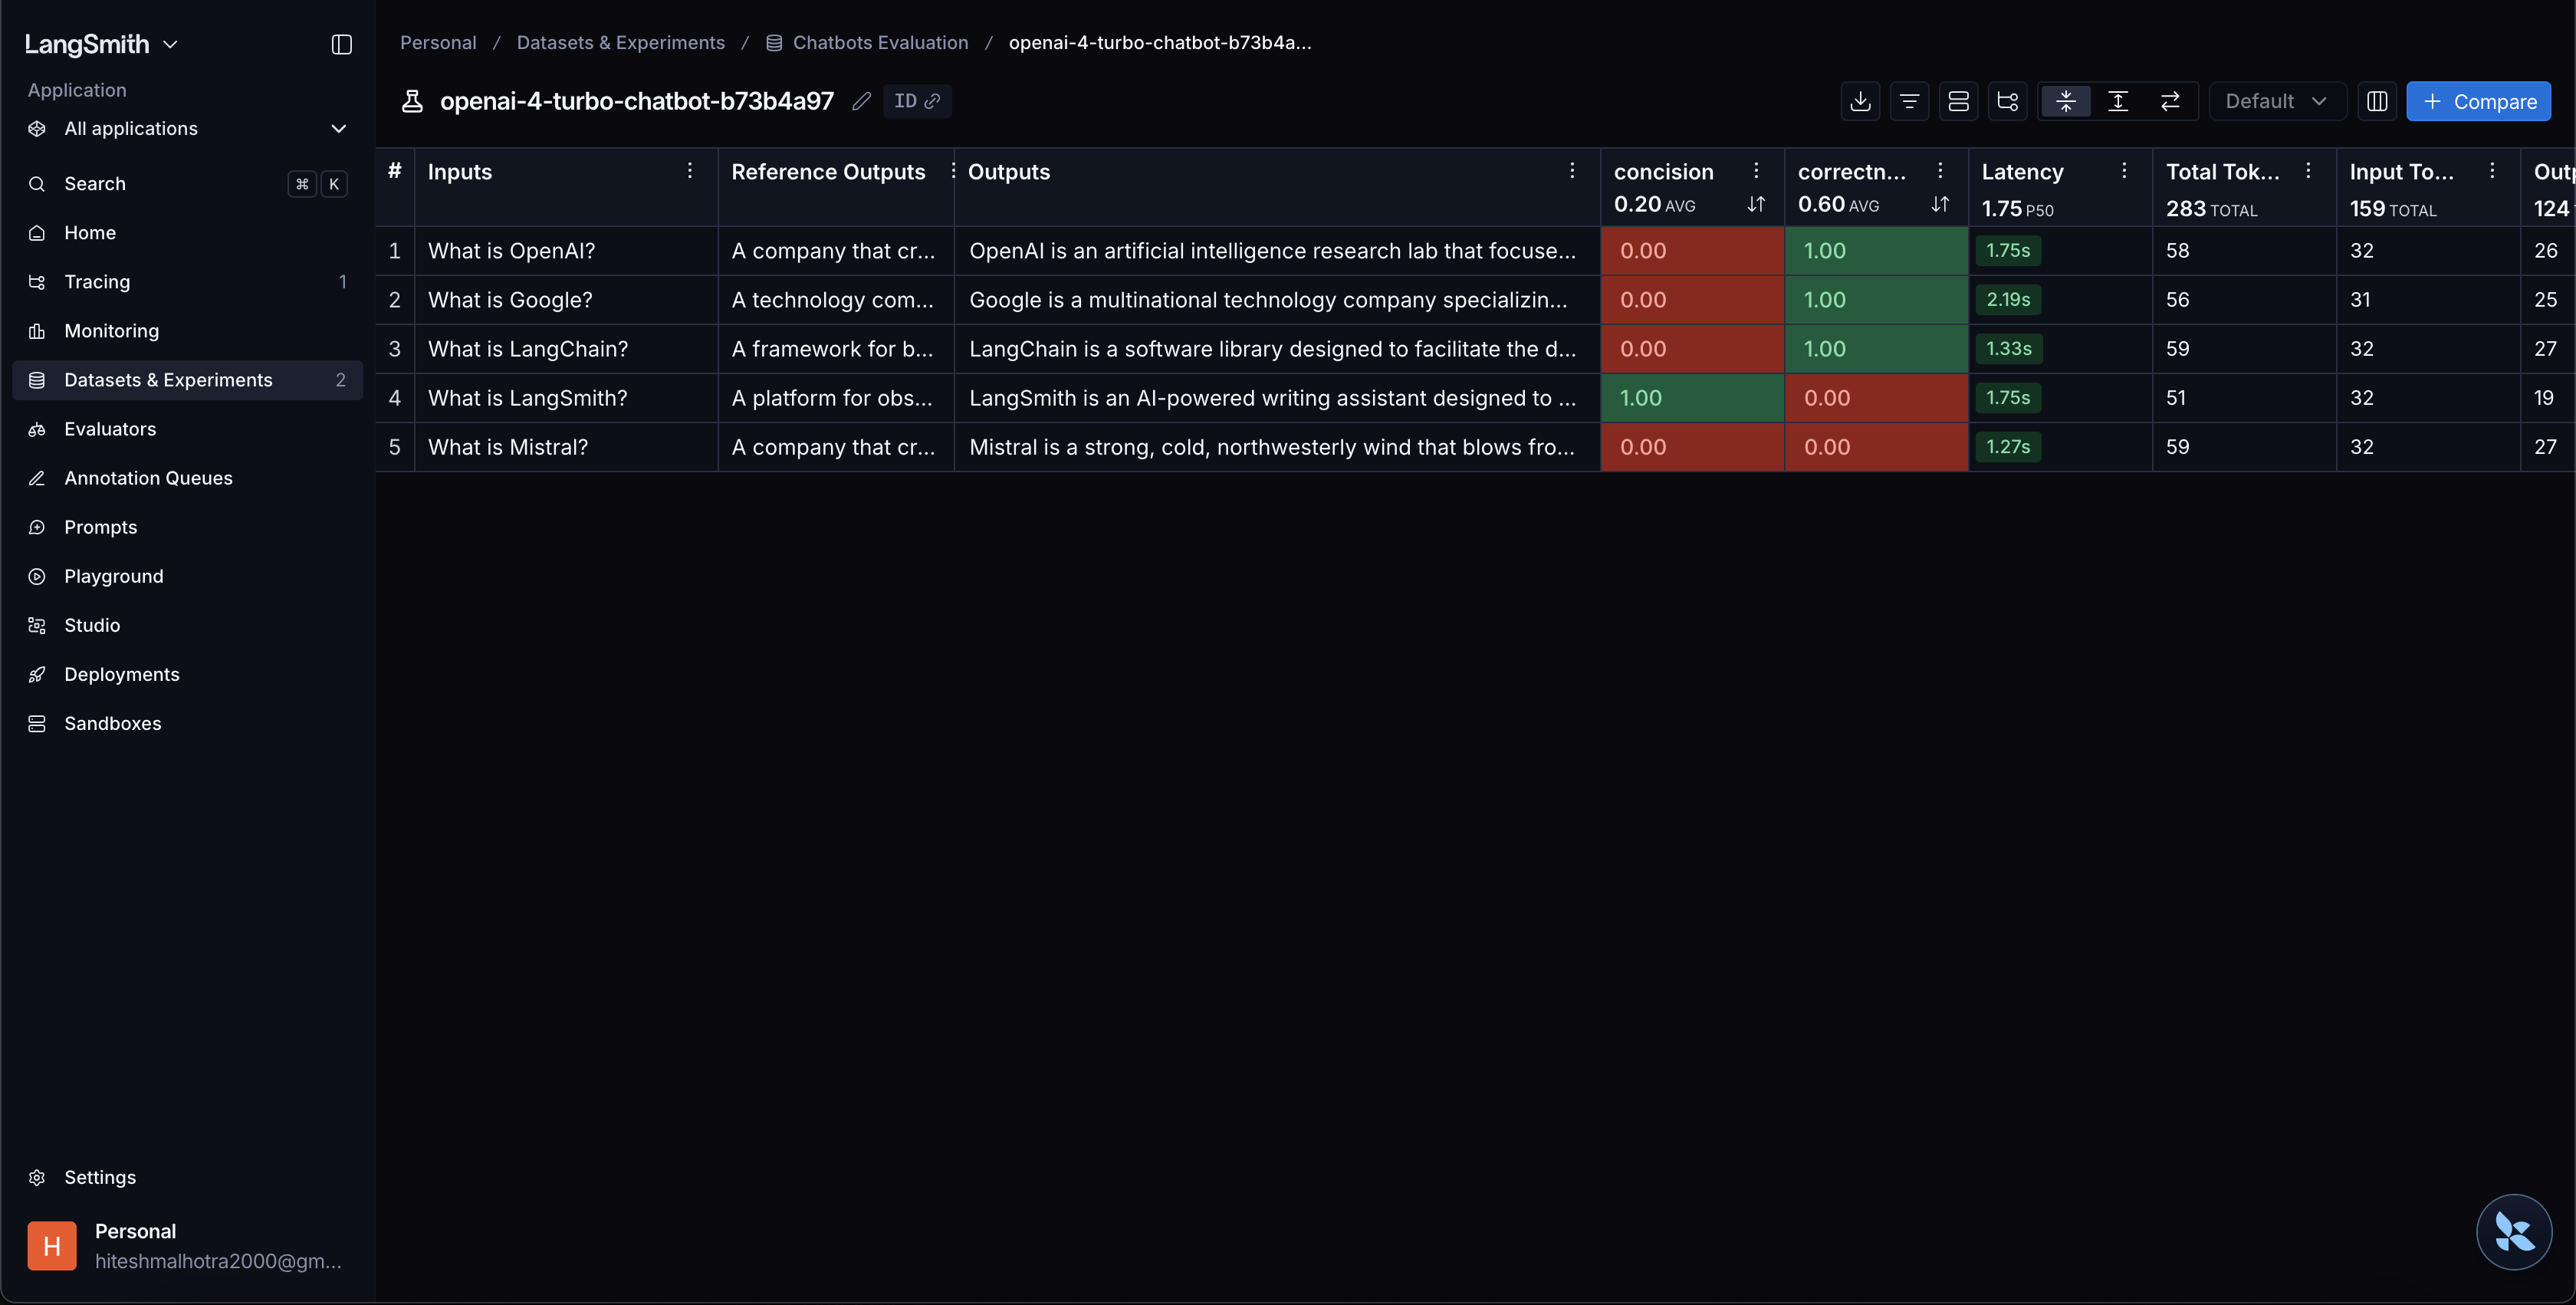